# XGBoost GPU + Optuna — GeoATM Popularity

**Данные:** `data/train_data_v2.csv` (6200 строк, ~134 признака)  
**Модель:** XGBRegressor на GPU (tree_method='hist', device='cuda')  
**Подбор гиперпараметров:** Optuna (100 trials)  
**Метрика:** RMSE

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
DATA_PATH = Path('../data/train_data_v2.csv')
TARGET = 'target'
MODEL_SAVE_PATH = Path('../models/xgboost_gpu_optuna.json')

pd.set_option('display.float_format', '{:.4f}'.format)
print(f'XGBoost version: {xgb.__version__}')
print('OK')

XGBoost version: 3.1.3
OK


## 1. Загрузка данных

In [3]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(df[TARGET].describe())

Shape: (6200, 134)
count   6200.0000
mean       0.0008
std        0.0859
min       -0.1450
25%       -0.0612
50%       -0.0155
75%        0.0402
max        0.2186
Name: target, dtype: float64


## 2. Определение признаков

In [4]:
BINARY_FEATURES = [
    'is_24_7', 'contactless_tech', 'qr_codes', 'usd_available', 'eur_available',
    'cash_in', 'cash_out', 'cashless_pay', 'account_statement', 'access_for_disabled',
    'transfer_p2p', 'transfer_a2a', 'loan_payments',
    'is_federal_city', 'is_federal_district_capital', 'is_city_center',
]

DISTANCE_FEATURES = [
    'nearest_malls_dist_m', 'nearest_supermarkets_dist_m',
    'nearest_pharmacies_hospitals_dist_m', 'nearest_cafes_dist_m',
    'nearest_restaurants_dist_m', 'nearest_public_transport_dist_m',
    'nearest_parking_dist_m', 'nearest_education_dist_m',
    'nearest_subway_dist_m', 'nearest_post_offices_dist_m',
    'nearest_offices_dist_m', 'nearest_shops_food_small_dist_m',
    'nearest_fitness_sport_dist_m', 'nearest_hotels_hostels_dist_m',
    'land_use_dist_m', 'city_center_dist_m', 'nearest_residential_landuse_dist_m',
]

COUNT_FEATURES = [
    'count_malls_300m', 'count_supermarkets_300m',
    'count_pharmacies_hospitals_300m', 'count_banks_atms_300m',
    'count_cafes_300m', 'count_restaurants_300m',
    'count_public_transport_300m', 'count_parking_300m',
    'count_education_300m', 'count_post_offices_300m',
    'count_offices_300m', 'count_payment_terminals_300m',
    'count_money_transfer_300m', 'count_shops_food_small_300m',
    'count_hypermarkets_300m', 'count_markets_300m',
    'count_fitness_sport_300m', 'count_hotels_hostels_300m',
    'count_railway_stations_300m', 'count_residential_buildings_300m',
    'count_residential_landuse_300m', 'count_fuel_300m',
    'count_highway_pedestrian_300m', 'count_landuse_mix_300m',
    'count_footway_100m_100m',
]

ECONOMIC_FEATURES = [
    'avg_salary_oct_2025_rub', 'grp_per_capita_2023_rub',
    'population', 'avg_income_q3_2025_rub',
]

CATEGORICAL_FEATURES = [
    'federal_district', 'city_size_category', 'land_use_type', 'atm_group',
]

ALL_FEATURES = BINARY_FEATURES + DISTANCE_FEATURES + COUNT_FEATURES + ECONOMIC_FEATURES + CATEGORICAL_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]
print(f'Итого признаков: {len(ALL_FEATURES)}')


Итого признаков: 66


## 3. Подготовка данных

In [5]:
X = df[ALL_FEATURES].copy()
y = df[TARGET].astype(float)

# bool → int
for col in BINARY_FEATURES:
    if col in X.columns and X[col].dtype == bool:
        X[col] = X[col].astype(int)

# atm_group: float → str для OrdinalEncoder
X['atm_group'] = X['atm_group'].astype(str)

# Стратификация по city_size_category
strat_col = df['city_size_category'].fillna('unknown')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=strat_col
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train target: mean={y_train.mean():.4f}, std={y_train.std():.4f}')
print(f'Test  target: mean={y_test.mean():.4f}, std={y_test.std():.4f}')

Train: (4960, 66), Test: (1240, 66)
Train target: mean=0.0011, std=0.0856
Test  target: mean=-0.0001, std=0.0873


## 4. Препроцессинг

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer

bin_cols  = [f for f in BINARY_FEATURES  if f in X.columns]
dist_cols = [f for f in DISTANCE_FEATURES if f in X.columns]
cnt_cols  = [f for f in COUNT_FEATURES   if f in X.columns]
econ_cols = [f for f in ECONOMIC_FEATURES if f in X.columns]
cat_cols  = [f for f in CATEGORICAL_FEATURES if f in X.columns]

log1p_tf = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

bin_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
])
dist_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p',   log1p_tf),
    ('scaler',  StandardScaler()),
])
count_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
econ_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('binary',   bin_pipe,   bin_cols),
        ('distance', dist_pipe,  dist_cols),
        ('count',    count_pipe, cnt_cols),
        ('economic', econ_pipe,  econ_cols),
        ('cat',      cat_pipe,   cat_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=True,
)

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)
feat_names   = preprocessor.get_feature_names_out()
print(f'Transformed shape: {X_train_prep.shape}')


Transformed shape: (4960, 66)


## 5. DMatrix (XGBoost native format)

In [7]:
dtrain = xgb.DMatrix(X_train_prep, label=y_train, feature_names=list(feat_names))
dtest  = xgb.DMatrix(X_test_prep,  label=y_test,  feature_names=list(feat_names))
print(f'DMatrix train: {dtrain.num_row()} rows x {dtrain.num_col()} cols')

DMatrix train: 4960 rows x 66 cols


## 6. Baseline XGBoost GPU

In [8]:
base_params = {
    'objective':       'reg:squarederror',
    'eval_metric':     'rmse',
    'tree_method':     'hist',
    'device':          'cuda',
    'learning_rate':   0.05,
    'max_depth':       6,
    'subsample':       0.8,
    'colsample_bytree': 0.8,
    'seed':            RANDOM_STATE,
}

evals_result = {}
xgb_baseline = xgb.train(
    base_params,
    dtrain,
    num_boost_round=1000,
    evals=[(dtest, 'test')],
    early_stopping_rounds=50,
    evals_result=evals_result,
    verbose_eval=100,
)

y_pred_base = xgb_baseline.predict(dtest)
rmse_base = np.sqrt(mean_squared_error(y_test, y_pred_base))
mae_base  = mean_absolute_error(y_test, y_pred_base)
r2_base   = r2_score(y_test, y_pred_base)
print(f'\nBaseline  RMSE={rmse_base:.4f}  MAE={mae_base:.4f}  R²={r2_base:.4f}')

[0]	test-rmse:0.08542
[100]	test-rmse:0.04615
[200]	test-rmse:0.04571
[300]	test-rmse:0.04556
[362]	test-rmse:0.04560

Baseline  RMSE=0.0456  MAE=0.0362  R²=0.7268


## 7. Optuna — подбор гиперпараметров (100 trials)

In [9]:
def objective(trial):
    params = {
        'objective':        'reg:squarederror',
        'eval_metric':      'rmse',
        'tree_method':      'hist',
        'device':           'cuda',
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'colsample_bylevel':trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'seed':             RANDOM_STATE,
    }
    result = xgb.train(
        params,
        dtrain,
        num_boost_round=1000,
        evals=[(dtest, 'test')],
        early_stopping_rounds=50,
        verbose_eval=False,
    )
    pred = result.predict(dtest)
    return np.sqrt(mean_squared_error(y_test, pred))

study = optuna.create_study(direction='minimize', study_name='xgboost_gpu')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest RMSE: {study.best_value:.4f}')
print('Best params:', study.best_params)

Best trial: 52. Best value: 0.0452538: 100%|██████████| 100/100 [00:44<00:00,  2.27it/s]


Best RMSE: 0.0453
Best params: {'learning_rate': 0.03097614101875342, 'max_depth': 6, 'min_child_weight': 4, 'subsample': 0.7966458639717744, 'colsample_bytree': 0.5225174295274988, 'colsample_bylevel': 0.7229647374426105, 'reg_alpha': 5.5009019626001304e-08, 'reg_lambda': 0.0025437147265183454, 'gamma': 0.00027624627525518145}


## 8. Финальная модель с лучшими параметрами

In [10]:
final_params = dict(study.best_params)
final_params.update({
    'objective':    'reg:squarederror',
    'eval_metric':  'rmse',
    'tree_method':  'hist',
    'device':       'cuda',
    'seed':         RANDOM_STATE,
})

xgb_final = xgb.train(
    final_params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtest, 'test')],
    early_stopping_rounds=50,
    verbose_eval=100,
)

y_pred_final = xgb_final.predict(dtest)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final  = mean_absolute_error(y_test, y_pred_final)
r2_final   = r2_score(y_test, y_pred_final)
print(f'\nFinal     RMSE={rmse_final:.4f}  MAE={mae_final:.4f}  R²={r2_final:.4f}')
print(f'Baseline  RMSE={rmse_base:.4f}')
print(f'Δ RMSE = {rmse_base - rmse_final:+.4f}')

[0]	test-rmse:0.08618
[100]	test-rmse:0.04743
[200]	test-rmse:0.04573
[300]	test-rmse:0.04544
[400]	test-rmse:0.04528
[441]	test-rmse:0.04525

Final     RMSE=0.0453  MAE=0.0361  R²=0.7309
Baseline  RMSE=0.0456
Δ RMSE = +0.0003


## 9. Важность признаков

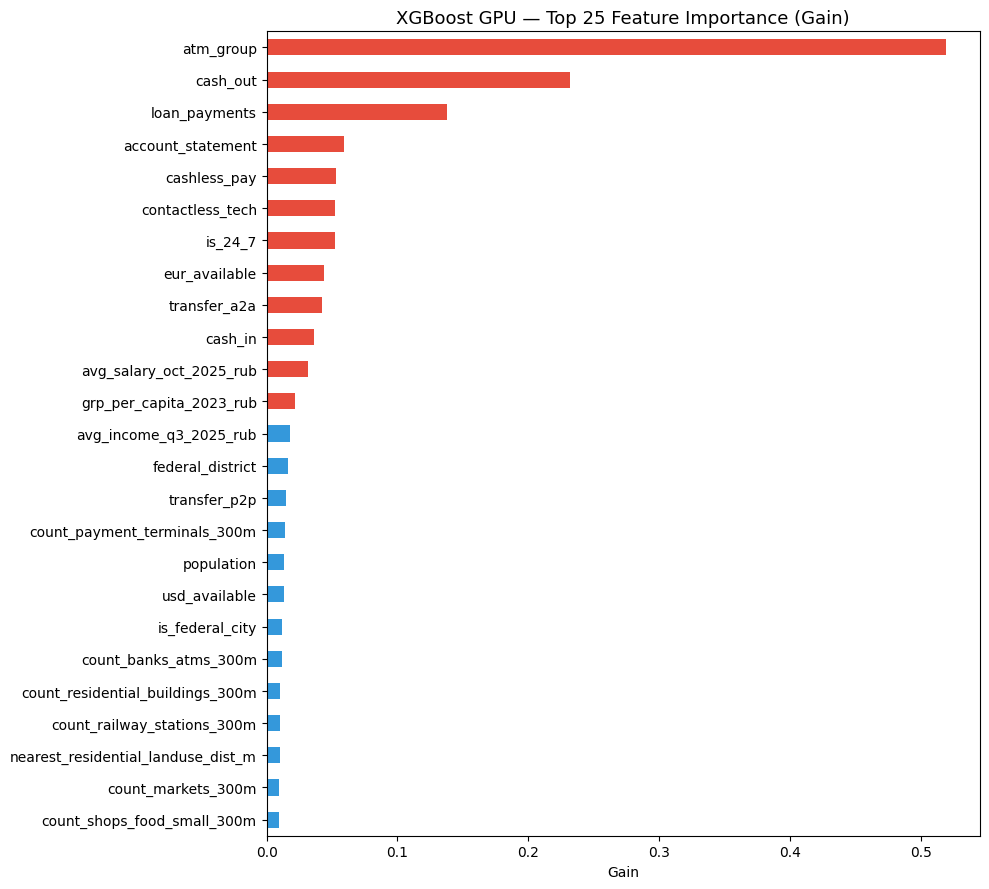


Top 15 features:
atm_group                 0.5191
cash_out                  0.2320
loan_payments             0.1377
account_statement         0.0592
cashless_pay              0.0531
contactless_tech          0.0523
is_24_7                   0.0519
eur_available             0.0436
transfer_a2a              0.0422
cash_in                   0.0366
avg_salary_oct_2025_rub   0.0314
grp_per_capita_2023_rub   0.0221
avg_income_q3_2025_rub    0.0179
federal_district          0.0166
transfer_p2p              0.0146


In [11]:
scores = xgb_final.get_score(importance_type='gain')
feat_imp = pd.Series(scores).sort_values(ascending=False)

# Очищаем префиксы от ColumnTransformer
feat_imp.index = [n.split('__', 1)[-1] if '__' in n else n for n in feat_imp.index]

fig, ax = plt.subplots(figsize=(10, 9))
top25 = feat_imp.head(25).iloc[::-1]
median_imp = top25.median()
colors = ['#e74c3c' if v > median_imp else '#3498db' for v in top25.values]
top25.plot.barh(ax=ax, color=colors)
ax.set_title('XGBoost GPU — Top 25 Feature Importance (Gain)', fontsize=13)
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

print('\nTop 15 features:')
print(feat_imp.head(15).to_string())

## 10. Сохранение модели

In [12]:
MODEL_SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
xgb_final.save_model(str(MODEL_SAVE_PATH))
print(f'Model saved → {MODEL_SAVE_PATH}')
print(f'Best iteration: {xgb_final.best_iteration}')

Model saved → ..\models\xgboost_gpu_optuna.json
Best iteration: 391
